# inat-obs-scorer - Model Evaluation v0.2

**Task:**  Expert Review Prioritization Engine for iNaturalist   - will a Quebec Plantae Needs ID observation reach Research Grade within 365 days?  
**Population:** Observations with no external identifications at day 7 (no-ID subpopulation)  
**Test set:** 27,474 observations - 28.2% positive rate


---

## Setup

In [24]:
import json

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.calibration import calibration_curve
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

In [25]:
with open("artifacts/test_metrics.json") as f:
    metrics = json.load(f)

y_test = np.load("artifacts/y_test.npy")
y_proba = np.load("artifacts/y_proba.npy")

shap_vals = np.load("artifacts/shap_values.npy")
X_transformed = pd.read_parquet("artifacts/X_test.parquet")

lift_df = pd.DataFrame(metrics["lift_table"])
lift_df["k_pct_label"] = (lift_df["k_pct"] * 100).apply(lambda x: f"{x:g}%")

print(
    f"Test set : {metrics['n_test']:,} observations  "
    "|  positive rate: {metrics['positive_rate']:.1%}"
)
print(f"PR-AUC   : {metrics['pr_auc']:.3f}  |  Brier: {metrics['brier_score']:.3f}")

Test set : 27,474 observations  |  positive rate: {metrics['positive_rate']:.1%}
PR-AUC   : 0.743  |  Brier: 0.134


## Ranking Metrics

In [26]:
display(
    lift_df[["k_pct_label", "n_reviewed", "recall_at_k", "precision_at_k", "lift_at_k"]]
    .rename(
        columns={
            "k_pct_label": "Top K%",
            "n_reviewed": "N reviewed",
            "recall_at_k": "Recall@K",
            "precision_at_k": "Precision@K",
            "lift_at_k": "Lift@K",
        }
    )
    .style.format({"Recall@K": "{:.1%}", "Precision@K": "{:.1%}", "Lift@K": "{:.2f}x"})
    .hide(axis="index")
)

Top K%,N reviewed,Recall@K,Precision@K,Lift@K
0.5%,137,1.7%,98.5%,3.45x
1%,274,3.4%,98.5%,3.45x
5%,1373,16.4%,93.9%,3.29x
10%,2747,30.6%,87.4%,3.06x
20%,5494,52.5%,74.9%,2.62x
50%,13737,88.7%,50.6%,1.77x


## Core Evaluation Plots

Two views of the same model: how well it ranks PR curve and lift.

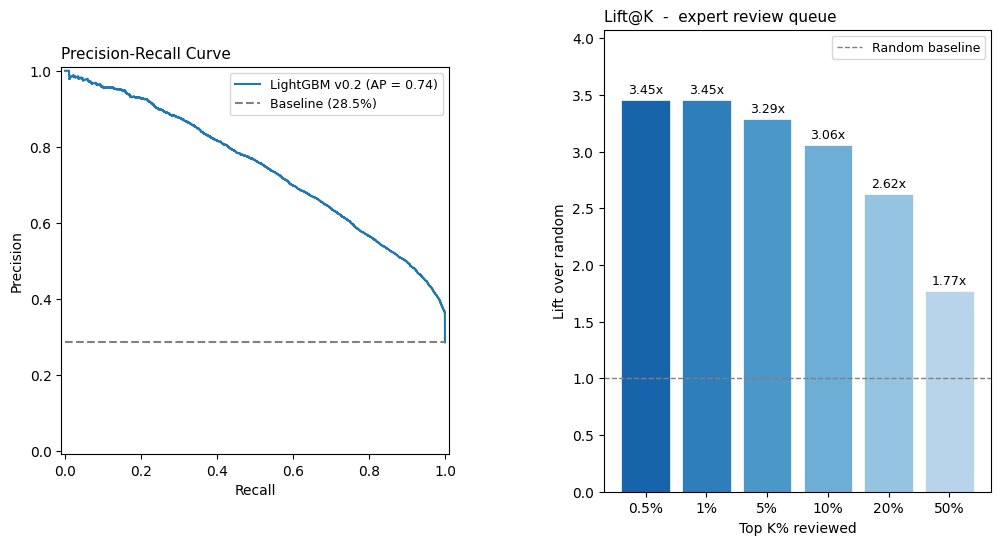

In [27]:
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4, width_ratios=[1, 1])

# 1. Precision-Recall curve
ax1 = fig.add_subplot(gs[0])

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    name="LightGBM v0.2",
    plot_chance_level=True,
    chance_level_kw={
        "linestyle": "--",
        "color": "grey",
        "label": f"Baseline ({metrics['positive_rate']:.1%})",
    },
    ax=ax1,
)
ax1.set_title("Precision-Recall Curve", fontsize=11, loc="left")
ax1.set_xlabel("Recall")
ax1.set_ylabel("Precision")
ax1.legend(fontsize=9)

# 2. Lift@K bar chart
ax2 = fig.add_subplot(gs[1])
bars = ax2.bar(
    lift_df["k_pct_label"],
    lift_df["lift_at_k"],
    color=plt.cm.Blues_r(np.linspace(0.2, 0.7, len(lift_df))),
    edgecolor="white",
    linewidth=0.5,
)
ax2.axhline(1.0, color="grey", linestyle="--", linewidth=1, label="Random baseline")
for bar, val in zip(bars, lift_df["lift_at_k"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{val:.2f}x",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax2.set_title("Lift@K  -  expert review queue", fontsize=11, loc="left")
ax2.set_xlabel("Top K% reviewed")
ax2.set_ylabel("Lift over random")
ax2.set_ylim(0, lift_df["lift_at_k"].max() * 1.18)
ax2.legend(fontsize=9)

plt.savefig("artifacts/evaluation_panel.png", dpi=150, bbox_inches="tight")
plt.show()

# Shap evaluation plot

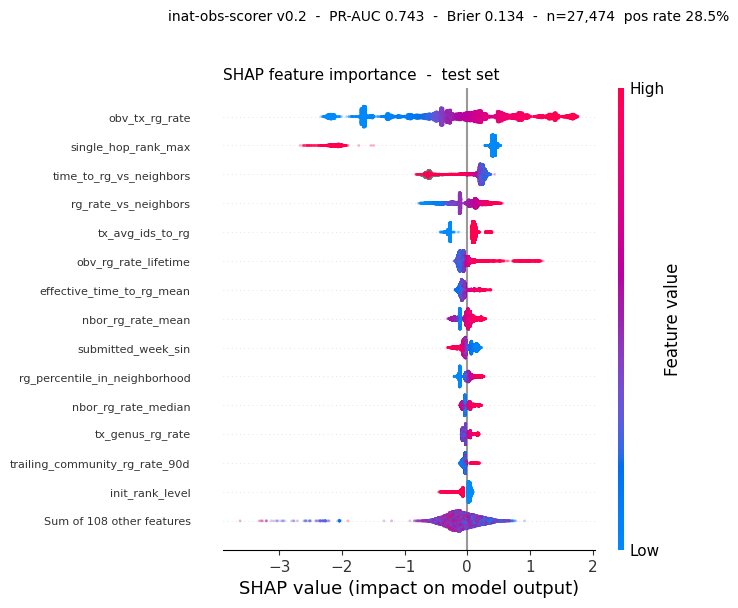

In [28]:
# 3. SHAP beeswarm
fig = plt.figure(figsize=(6, 6))
ax1 = fig.add_subplot()
explanation = shap.Explanation(
    values=shap_vals,
    data=X_transformed.values,
    feature_names=X_transformed.columns.tolist(),
)
shap.plots.beeswarm(
    explanation, max_display=15, s=4, alpha=0.3, show=False, ax=ax1, plot_size=None
)
ax1.set_title("SHAP feature importance  -  test set", fontsize=11, loc="left")
ax1.tick_params(axis="y", labelsize=8)

fig.suptitle(
    f"inat-obs-scorer v0.2  -  PR-AUC {metrics['pr_auc']:.3f}  -  "
    f"Brier {metrics['brier_score']:.3f}  -  "
    f"n={metrics['n_test']:,}  pos rate {metrics['positive_rate']:.1%}",
    fontsize=10,
    y=1.01,
)
plt.savefig("artifacts/shap_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## Probability Calibration

LightGBM is systematically underconfident at this positive rate. Platt scaling is planned for v0.3.

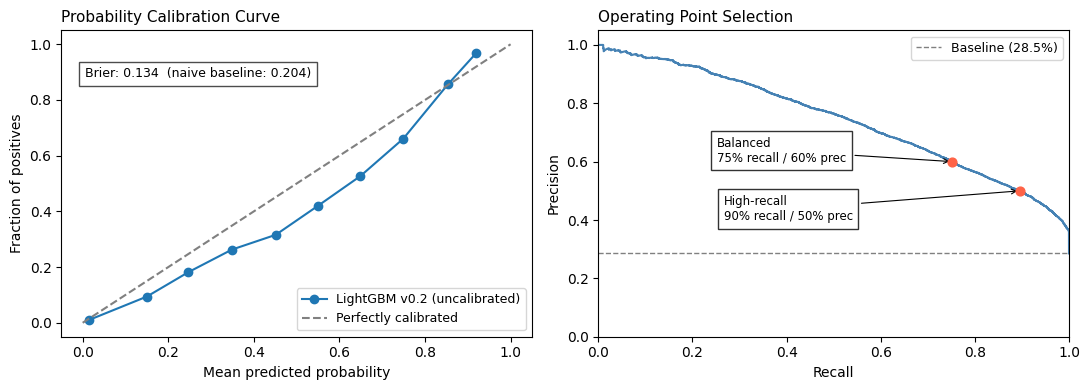

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Calibration curve
ax = axes[0]
true_frac, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
ax.plot(
    mean_pred,
    true_frac,
    marker="o",
    linewidth=1.5,
    label="LightGBM v0.2 (uncalibrated)",
)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
ax.set_title("Probability Calibration Curve", fontsize=11, loc="left")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend(fontsize=9)
naive_brier = metrics["positive_rate"] * (1 - metrics["positive_rate"])
ax.text(
    0.05,
    0.88,
    f"Brier: {metrics['brier_score']:.3f}  (naive baseline: {naive_brier:.3f})",
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    bbox=dict(facecolor="white", alpha=0.7),
)

# Operating point
ax = axes[1]
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_proba)
ax.plot(recall_arr, precision_arr, linewidth=1.5, color="steelblue")
ax.axhline(
    metrics["positive_rate"],
    linestyle="--",
    color="grey",
    linewidth=1,
    label=f"Baseline ({metrics['positive_rate']:.1%})",
)

idx1 = np.argmin(np.abs(precision_arr - 0.5))
idx2 = np.argmin(np.abs(precision_arr - 0.6))

ax.annotate(
    "High-recall\n90% recall / 50% prec",
    xy=(recall_arr[idx1], precision_arr[idx1]),
    xytext=(recall_arr[idx1] - 0.63, (precision_arr[idx1] - 0.1)),
    arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
    fontsize=8.5,
    bbox=dict(facecolor="white", alpha=0.8),
)
ax.annotate(
    "Balanced\n75% recall / 60% prec",
    xy=(recall_arr[idx2], precision_arr[idx2]),
    xytext=(recall_arr[idx2] - 0.5, (precision_arr[idx2])),
    arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
    fontsize=8.5,
    bbox=dict(facecolor="white", alpha=0.8),
)
ax.scatter(recall_arr[idx1], precision_arr[idx1], zorder=5, s=40, color="tomato")
ax.scatter(recall_arr[idx2], precision_arr[idx2], zorder=5, s=40, color="tomato")

ax.set_title("Operating Point Selection", fontsize=11, loc="left")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()